In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
num_rows=500
start_date = datetime(2026,1,1)

# make products

products={
    'Grocery':{'Milk':28,'Bread':12.5,'Butter':18},
    'Electronics':{'Headphone':750,'Charging Cable':100,'Iron':250},
    'Cloths':{'T-Shirt':150,'Prit T-shirt':300,'paint':250,'Jeans':750}
}
categories=list(products.keys())
chosen_category = random.choice(categories)

# user payment_method
payment_method=['Cash','Credit Card','UPI']

#making data list
data=[]

current_tx_id=1001

In [ ]:
# creating a data

while len(data)< num_rows:
  tx_date=start_date + timedelta(minutes=random.randint(5,60))
  customer_id=f"C{random.randint(5000,5500)}"
  pay_method=random.choice(payment_method)

  tx_size=random.randint(1,3)
  bought_items=[]

  for i in range(tx_size):
    if len(data) >= num_rows:
      break

    category = random.choice(categories)
    product=random.choice(list(products[chosen_category].keys()))


    price = products[chosen_category][product]
    qty=random.randint(1,2)
    data.append({
            'Transaction_ID': f"T{current_tx_id}",
            'Customer_ID': customer_id,
            'Date_Time': tx_date.strftime('%Y-%m-%d %H:%M'),
            'Product_Category': category,
            'Product_Name': product,
            'Quantity': qty,
            'Price_Per_Unit': price,
            'Payment_Method': pay_method
        })
    customer_id=customer_id+1
    bought_items.append(product)






In [ ]:
# now creating dataframe
df= pd.DataFrame(data)

In [ ]:
df

,Transaction_ID,Customer_ID,Date_Time,Product_Category,Product_Name,Quantity,Price_Per_Unit,Payment_Method
0,T1001,C5298,2026-01-01 00:10,Electronics,Bread,1,12.5,UPI
1,T1001,C5298,2026-01-01 00:10,Electronics,Butter,1,18.0,UPI
2,T1001,C5057,2026-01-01 00:33,Cloths,Milk,2,28.0,Credit Card
3,T1001,C5057,2026-01-01 00:33,Grocery,Butter,1,18.0,Credit Card
4,T1001,C5225,2026-01-01 00:17,Cloths,Bread,2,12.5,Credit Card
...,...,...,...,...,...,...,...,...
495,T1001,C5327,2026-01-01 00:23,Cloths,Bread,2,12.5,UPI
496,T1001,C5207,2026-01-01 00:25,Cloths,Bread,1,12.5,Cash
497,T1001,C5071,2026-01-01 00:23,Grocery,Bread,1,12.5,Cash
498,T1001,C5071,2026-01-01 00:23,Electronics,Bread,2,12.5,Cash


In [ ]:
df['Total_Amount'] = df['Quantity'] * df['Price_Per_Unit']

In [ ]:
df.head()

,Transaction_ID,Customer_ID,Date_Time,Product_Category,Product_Name,Quantity,Price_Per_Unit,Payment_Method,Total_Amount
0,T1001,C5298,2026-01-01 00:10:00,Electronics,Bread,1,12.5,UPI,12.5
1,T1001,C5298,2026-01-01 00:10:00,Electronics,Butter,1,18.0,UPI,18.0
2,T1001,C5057,2026-01-01 00:33:00,Cloths,Milk,2,28.0,Credit Card,56.0
3,T1001,C5057,2026-01-01 00:33:00,Grocery,Butter,1,18.0,Credit Card,18.0
4,T1001,C5225,2026-01-01 00:17:00,Cloths,Bread,2,12.5,Credit Card,25.0


In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
Customer_ID,0
Date_Time,0
Product_Category,0
Product_Name,0
Quantity,0
Price_Per_Unit,0
Payment_Method,0
Total_Amount,0


In [ ]:
df.shape

(500, 9)

In [ ]:
df.describe()

,Date_Time,Quantity,Price_Per_Unit,Total_Amount
count,500,500.000000,500.000000,500.00000
mean,2026-01-01 00:32:46.200000,1.462000,19.109000,28.00300
min,2026-01-01 00:05:00,1.000000,12.500000,12.50000
25%,2026-01-01 00:19:00,1.000000,12.500000,18.00000
50%,2026-01-01 00:31:00,1.000000,18.000000,25.00000
75%,2026-01-01 00:47:00,2.000000,28.000000,36.00000
max,2026-01-01 01:00:00,2.000000,28.000000,56.00000
std,NaN,0.499053,6.387662,13.88752


In [ ]:
#cheaking inforamiton
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    500 non-null    object        
 1   Customer_ID       500 non-null    object        
 2   Date_Time         500 non-null    datetime64[ns]
 3   Product_Category  500 non-null    object        
 4   Product_Name      500 non-null    object        
 5   Quantity          500 non-null    int64         
 6   Price_Per_Unit    500 non-null    float64       
 7   Payment_Method    500 non-null    object        
 8   Total_Amount      500 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 35.3+ KB


In [ ]:
#EDA
# here Date_Time  datatype show object so change it
df['Date_Time']= pd.to_datetime(df['Date_Time'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    500 non-null    object        
 1   Customer_ID       500 non-null    object        
 2   Date_Time         500 non-null    datetime64[ns]
 3   Product_Category  500 non-null    object        
 4   Product_Name      500 non-null    object        
 5   Quantity          500 non-null    int64         
 6   Price_Per_Unit    500 non-null    float64       
 7   Payment_Method    500 non-null    object        
 8   Total_Amount      500 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 35.3+ KB


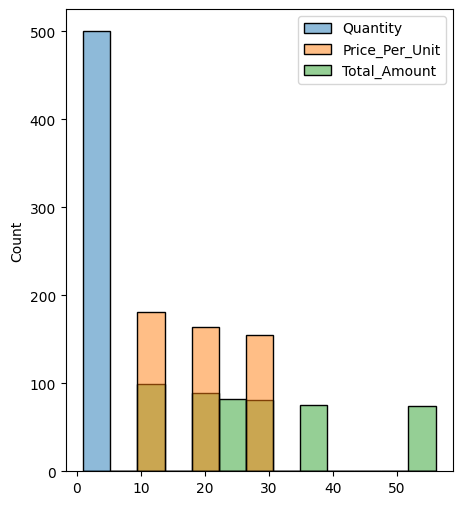

In [ ]:
plt.figure(figsize=(5,6))
sns.histplot(data=df)
plt.show()

<Axes: ylabel='Price_Per_Unit'>

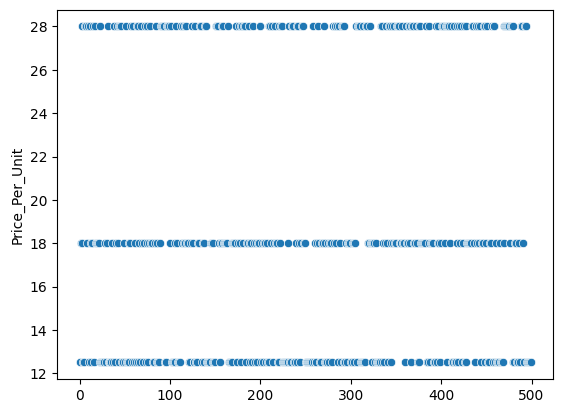

In [ ]:
sns.scatterplot(data=df['Price_Per_Unit'])

In [ ]:
from sklearn.cluster import KMeans

# gorup of by total spend or total visits

customer_df = df.groupby('Customer_ID').agg(
    Total_Spend=('Total_Amount', 'sum'),
    Total_Visits=('Transaction_ID', 'nunique')
).reset_index()

# setup k mean
kmeans = KMeans(n_clusters=3, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(customer_df[['Total_Spend', 'Total_Visits']])



In [ ]:
customer_df

,Customer_ID,Total_Spend,Total_Visits,Cluster
0,C5005,28.0,1,1
1,C5007,84.0,1,2
2,C5012,117.0,1,2
3,C5013,181.0,1,0
4,C5015,48.5,1,1
...,...,...,...,...
183,C5491,56.0,1,1
184,C5494,18.0,1,1
185,C5495,65.5,1,1
186,C5499,28.0,1,1


In [ ]:
# analyse the group
analysis = customer_df.groupby('Cluster').mean(numeric_only=True)
print(analysis)

         Total_Spend  Total_Visits
Cluster                           
0         166.870370           1.0
1          36.919192           1.0
2          94.209677           1.0
